<div class="alert alert-block alert-success">
    
# Case Study 📓: Predicting Conversion Rate
    
#### [**Case Study Link**](https://docs.google.com/document/d/1pt2PxePa2uLJOvgrveAF9L_mlabb6wHOs2xawqcBdK8/edit?usp=sharing)


 👨‍🏫 **Vikesh K**      



</div>

<div class="alert alert-block alert-danger">
    
# OH Agenda 📝
    
We will cover:

* ML Overview
* Conversion Case Study
    * EDA with respect to model building
    * Data Prep
    * Model Building
    * Business Insights
    
    
 </div>

##  <font color= darkred> Import modules and data </font>

In [1]:
# data manipulation
import pandas as pd
import numpy as np

# data viz
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn import dummy

warnings.filterwarnings("ignore")

# plt.style.use("fivethirtyeight") # styling the charts

**Load Data**

In [2]:
url = 'https://raw.githubusercontent.com/vkoul/data/main/misc/conversion_data.csv'

df = pd.read_csv(url)

In [3]:
df.sample(10)

,country,age,new_user,source,total_pages_visited,converted
7876,US,38,1,Direct,2,0
29751,US,17,1,Ads,2,0
224829,US,23,0,Direct,6,0
24086,US,33,1,Seo,1,0
88348,China,34,1,Seo,1,0
110907,US,27,1,Seo,4,0
193414,US,19,1,Seo,5,0
75760,US,19,1,Ads,4,0
177829,UK,17,1,Seo,3,0
1356,US,43,0,Ads,6,0


## Hypothesis


* **Data Quality**
  * Missing values
  * data types- if they are correct
  * duplicates
  * outliers

* **Exploration**
  * Univariate
    * kde, histogram
    * boxplots
    * bar charts
  * Bivariate analysis
    * scatter
    * bar chart
    * ratios
    * correlation for numeric

* **Pre-processing: before the modeling**
  * Imputation
  * Encoding - One Hot
  * Numerical - Standardisation

* **Modeling**

  * Knn- classification
  * Logistic Regression
  * Decision Trees Classifier
  * Random Forest Classifier


##  <font color= darkred> Data Inspection</font>🔍📊

### <font color= darkred> Numerical inspection and summaries </font>

**Data Inspect**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 316200 entries, 0 to 316199
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   country              316200 non-null  str  
 1   age                  316200 non-null  int64
 2   new_user             316200 non-null  int64
 3   source               316200 non-null  str  
 4   total_pages_visited  316200 non-null  int64
 5   converted            316200 non-null  int64
dtypes: int64(4), str(2)
memory usage: 14.5 MB


**Missing values check**

In [5]:
df.isna().sum()

country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

**Duplicates**

In [6]:
df.duplicated().sum()

np.int64(299903)

In [7]:
# df[df.duplicated()].sort_values(by = ["country", "age", "total_pages_visited"]).head(10)

In [8]:
df = df.drop_duplicates().copy()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(16297, 6)

##   <font color= darkred> EDA </font>

### Univariate Analysis

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 16297 entries, 0 to 316098
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   country              16297 non-null  str  
 1   age                  16297 non-null  int64
 2   new_user             16297 non-null  int64
 3   source               16297 non-null  str  
 4   total_pages_visited  16297 non-null  int64
 5   converted            16297 non-null  int64
dtypes: int64(4), str(2)
memory usage: 891.2 KB


In [12]:
df.head(3)

,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0


**Pie Chart**

In [13]:
df["converted"].value_counts()

converted
0    11969
1     4328
Name: count, dtype: int64

In [14]:
df["converted"].value_counts(normalize = True).round(2)

converted
0    0.73
1    0.27
Name: proportion, dtype: float64

In [15]:
df["converted"].mean().round(2)

np.float64(0.27)

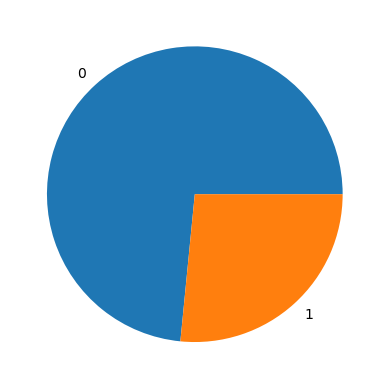

In [16]:
df["converted"].value_counts(normalize = True).plot(kind = "pie");

In [17]:
df.describe().round(2)

,age,new_user,total_pages_visited,converted
count,16297.00,16297.0,16297.00,16297.00
mean,33.85,0.5,9.00,0.27
std,11.46,0.5,5.42,0.44
min,17.00,0.0,1.00,0.00
25%,24.00,0.0,5.00,0.00
50%,32.00,1.0,9.00,0.00
75%,42.00,1.0,13.00,1.00
max,123.00,1.0,29.00,1.00


In [18]:
df.describe([0.85, 0.95, 0.99]).round(2) # pecrcentiles

,age,new_user,total_pages_visited,converted
count,16297.00,16297.0,16297.00,16297.00
mean,33.85,0.5,9.00,0.27
std,11.46,0.5,5.42,0.44
min,17.00,0.0,1.00,0.00
85%,47.00,1.0,15.00,1.00
95%,55.00,1.0,19.00,1.00
99%,61.00,1.0,23.00,1.00
max,123.00,1.0,29.00,1.00


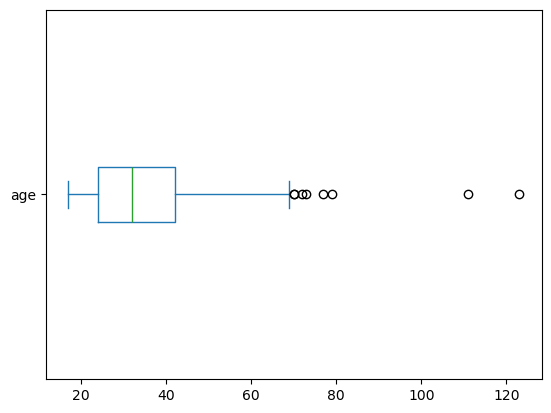

In [19]:
df["age"].plot(kind = "box", vert = False);

In [20]:
df = df.query("age < 80").copy()

In [21]:
df.shape

(16295, 6)

<Figure size 1000x500 with 0 Axes>

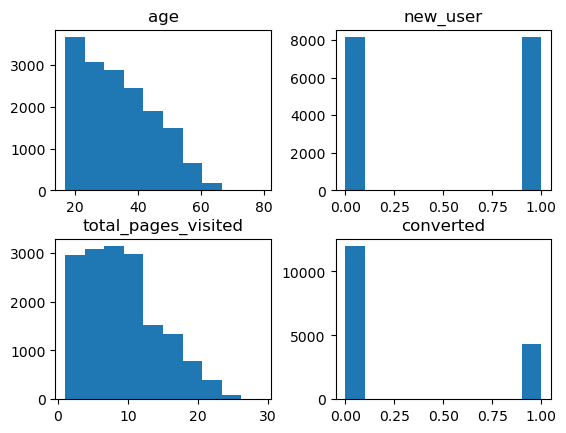

In [22]:
plt.figure(figsize = (10, 5));
df.hist(grid = False);

In [23]:
df.describe(include = "object")

,country,source
count,16295,16295
unique,4,3
top,US,Seo
freq,5814,6091


### Bivariate Analysis

In [24]:
# df.groupby("source").describe().T.round(2)

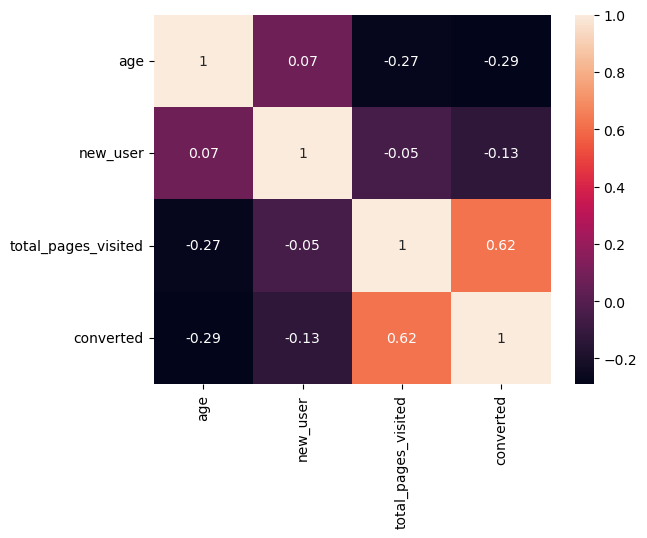

In [25]:
corr = df.corr(numeric_only = True).round(2)

sns.heatmap(corr, annot = True);

In [26]:
# df.groupby("country").corr(numeric_only = True).round(2)

**Categorical Values**

In [27]:
df.head()

,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0
3,China,39,1,Seo,5,0
4,US,30,1,Seo,6,0


In [28]:
cat_cols = df.select_dtypes("object").columns.tolist()
cat_cols

['country', 'source']

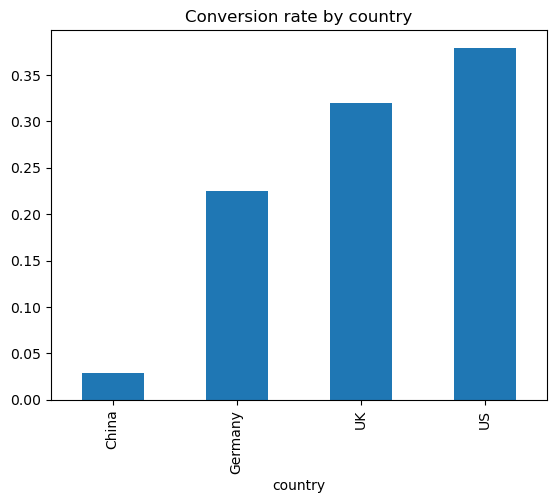

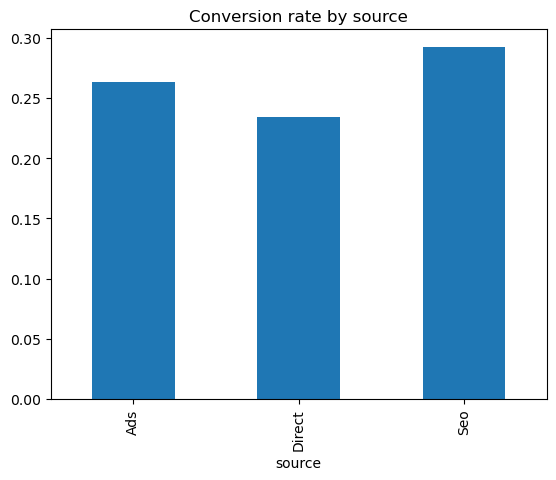

In [29]:
for cat in cat_cols:
    df.groupby(cat)["converted"].mean().plot(kind = "bar", title = f"Conversion rate by {cat}");
    plt.show();

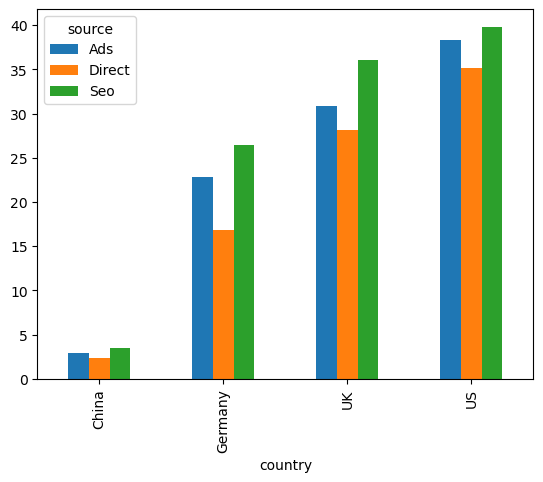

In [30]:
 df.groupby(["country", "source"])["converted"].mean().multiply(100).unstack().plot(kind = 'bar');

In [31]:
 df.groupby('source')["converted"].mean().multiply(100).round(2)

source
Ads       26.36
Direct    23.41
Seo       29.24
Name: converted, dtype: float64

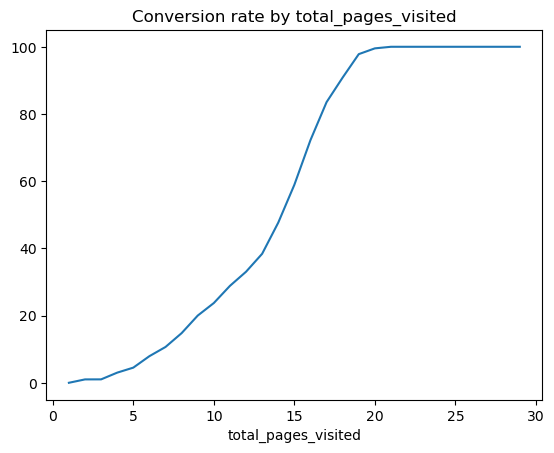

In [32]:

df.groupby('total_pages_visited')['converted'].mean().multiply(100).plot(kind = 'line', title = "Conversion rate by total_pages_visited");

In [33]:
df.groupby('age')['converted'].mean().multiply(100).plot(kind = 'line', backend = 'plotly')

In [34]:
X = df.drop(columns = ["converted"])
y = df["converted"]

In [35]:
X.info()

<class 'pandas.DataFrame'>
Index: 16295 entries, 0 to 316098
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   country              16295 non-null  str  
 1   age                  16295 non-null  int64
 2   new_user             16295 non-null  int64
 3   source               16295 non-null  str  
 4   total_pages_visited  16295 non-null  int64
dtypes: int64(3), str(2)
memory usage: 763.8 KB


In [36]:
from sklearn.model_selection import train_test_split

x_train_orig, x_test_orig, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [53]:
len(x_test_orig) / len(x_train_orig)

0.25

In [54]:
y.mean()

np.float64(0.265480208652961)

In [55]:
X.columns

Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='str')

In [56]:
numerical_columns = ['age', 'total_pages_visited']
categorical_columns = ['country', 'source']

In [57]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [58]:
X.head()

,country,age,new_user,source,total_pages_visited
0,UK,25,1,Ads,1
1,US,23,1,Seo,5
2,US,28,1,Seo,4
3,China,39,1,Seo,5
4,US,30,1,Seo,6


In [59]:
ct = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_columns),
    ('cat', OneHotEncoder(drop = "first", sparse_output=False), categorical_columns)], remainder="passthrough")
ct.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [60]:
x_train = ct.fit_transform(x_train_orig)
x_test = ct.transform(x_test_orig)

In [61]:
x_train.head()

,num__age,num__total_pages_visited,cat__country_Germany,cat__country_UK,cat__country_US,cat__source_Direct,cat__source_Seo,remainder__new_user
14097,1.062762,-1.105139,1.0,0.0,0.0,0.0,1.0,1
90073,-1.124563,1.294730,1.0,0.0,0.0,0.0,0.0,0
2195,0.362818,-1.474350,0.0,0.0,0.0,0.0,0.0,0
731,-0.162140,-0.920534,0.0,1.0,0.0,0.0,1.0,1
6951,-1.387042,-1.474350,0.0,0.0,1.0,1.0,0.0,1


In [62]:
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [63]:
y_train.mean()

np.float64(0.26403804848112916)

In [64]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
dummy.fit(x_train, y_train)

print(f"Dummy Classifier Accuracy for train: {dummy.score(x_train, y_train):.2%}")
print(f"Dummy Classifier Accuracy for test: {dummy.score(x_test, y_test):.2%}")


Dummy Classifier Accuracy for train: 73.60%
Dummy Classifier Accuracy for test: 72.88%


In [72]:
y_train.value_counts(normalize = True).round(2)

converted
0    0.74
1    0.26
Name: proportion, dtype: float64

k_nn model using KNeighboursClassifier

In [73]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
print(f"KNN Classifier Accuracy for train: {knn.score(x_train, y_train):.2%}")
print(f"KNN Classifier Accuracy for test: {knn.score(x_test, y_test):.2%}")

KNN Classifier Accuracy for train: 86.76%
KNN Classifier Accuracy for test: 81.37%


Decision Tree Classifier using DecitionTreeClassifier

In [74]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=None)
dt.fit(x_train, y_train)
print(f"Decision Tree Classifier Accuracy for train: {dt.score(x_train, y_train ):.2%}")
print(f"Decision Tree Classifier Accuracy for test: {dt.score(x_test, y_test):.2%}")

Decision Tree Classifier Accuracy for train: 89.91%
Decision Tree Classifier Accuracy for test: 73.98%


In [75]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3)
dt.fit(x_train, y_train)
print(f"Decision Tree Classifier Accuracy for train: {dt.score(x_train, y_train ):.2%}")
print(f"Decision Tree Classifier Accuracy for test: {dt.score(x_test, y_test):.2%}")

Decision Tree Classifier Accuracy for train: 84.29%
Decision Tree Classifier Accuracy for test: 83.86%


Random forest using RandomForestClassifier

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=7)
rf.fit(x_train, y_train)
print(f"Random Forest Classifier Accuracy for train: {rf.score(x_train, y_train):.2%}")
print(f"Random Forest Classifier Accuracy for test: {rf.score(x_test, y_test):.2%}")


Random Forest Classifier Accuracy for train: 85.81%
Random Forest Classifier Accuracy for test: 85.00%


Please fit a Logistic Regression model and check the accuracy for train and test data.

In [78]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
print(f"Logistic Regression Accuracy for train: {lr.score(x_train, y_train):.2%}")
print(f"Logistic Regression Accuracy for test: {lr.score(x_test, y_test):.2%}")

Logistic Regression Accuracy for train: 85.77%
Logistic Regression Accuracy for test: 85.06%


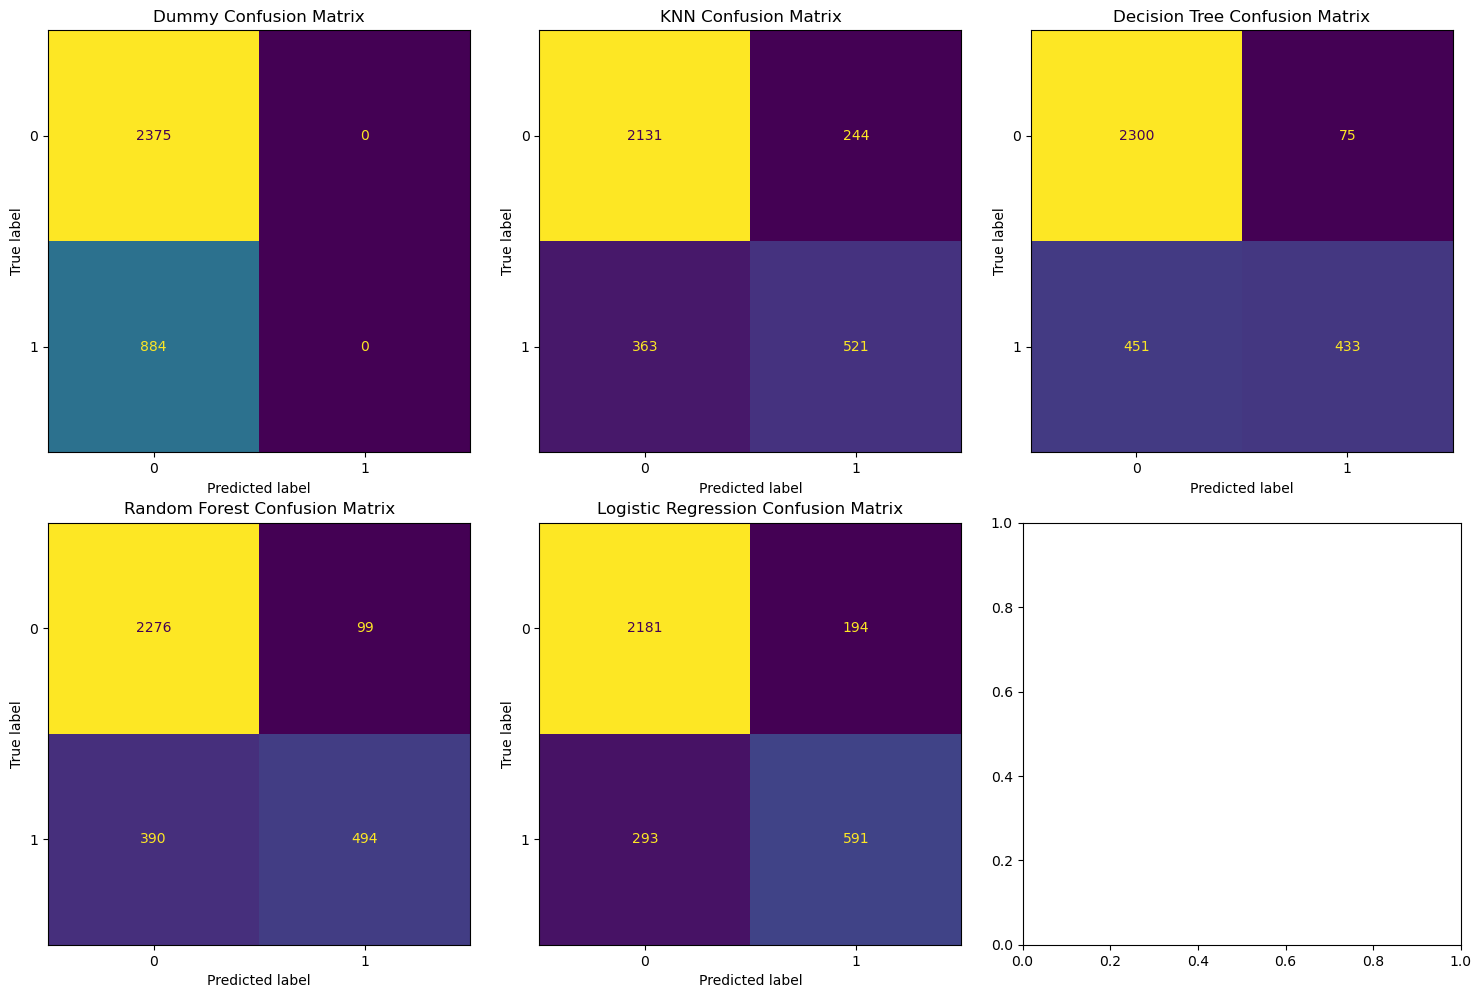

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

models = {
    "Dummy": dummy,
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Logistic Regression": lr
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (name, model) in zip(axes.ravel(), models.items()):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} Confusion Matrix")
plt.tight_layout()

In [83]:
def calculate_business_loss(y_true, y_pred, cost_fp=2.5, cost_fn=25):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_loss = (fp * cost_fp) + (fn * cost_fn)
    return total_loss

In [88]:
model_results = {}
for name, model in models.items():
    y_pred = model.predict(x_test)
    accuracy = model.score(x_test, y_test)
    business_loss = calculate_business_loss(y_test, y_pred)
    model_results[name] = business_loss

cost_df = pd.DataFrame.from_dict(model_results, orient='index', columns=['Total Loss ($)'])
cost_df.sort_values(by=['Total Loss ($)'], inplace=True)
display(cost_df.sort_values(by='Total Loss ($)', ascending=True))


,Total Loss ($)
Logistic Regression,7810.0
KNN,9685.0
Random Forest,9997.5
Decision Tree,11462.5
Dummy,22100.0


<div class="alert alert-block alert-success">

# Reference material 📚


* [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/): good book for hands on practice and codes.
* [ISLR](https://www.statlearning.com/)- covers theory nicely
    
</div>